In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 7 tables
match_stats = pd.read_csv('MatchStatsTbl.csv')
match = pd.read_csv('MatchTbl.csv')
team_match = pd.read_csv('TeamMatchTbl.csv')
summoner_match = pd.read_csv('SummonerMatchTbl.csv')
rank = pd.read_csv('RankTbl.csv')
champion = pd.read_csv('ChampionTbl.csv')
item = pd.read_csv('ItemTbl.csv')

print("MatchStatsTbl:", match_stats.shape)
print("MatchTbl:", match.shape)
print("TeamMatchTbl:", team_match.shape)
print("SummonerMatchTbl:", summoner_match.shape)

MatchStatsTbl: (732308, 31)
MatchTbl: (279423, 5)
TeamMatchTbl: (214330, 24)
SummonerMatchTbl: (707832, 4)


In [ ]:
# ============================================================
# STEP 1: Filter to CLASSIC queue only
# CLASSIC = standard 5v5 matches, the main game mode in LoL
# We exclude ARAM, URF etc. because they have different rules
# and would distort our win prediction model
# ============================================================
classic_matches = match[match['QueueType'] == 'CLASSIC']
print("Total matches:", len(match))
print("CLASSIC matches:", len(classic_matches))

# ============================================================
# STEP 2: Merge rank names onto matches
# MatchTbl only stores RankFk (a number like 4, 5, 6)
# We join RankTbl to convert those numbers to readable names
# like "Gold", "Platinum", "Diamond"
# ============================================================
classic_matches = classic_matches.merge(rank, left_on='RankFk', right_on='RankId', how='left')
print("\nRank distribution in CLASSIC matches:")
print(classic_matches['RankName'].value_counts())

# ============================================================
# STEP 3: Check game duration distribution
# GameDuration is in seconds — a normal LoL game is 25-35 mins
# Very short games (<10 min) may be surrenders or remakes
# Very long games (>60 min) are outliers
# This helps us decide if we need to filter any extreme values
# ============================================================
print("\nGame duration stats (seconds):")
print(classic_matches['GameDuration'].describe())

# ============================================================
# STEP 4: Check patch distribution
# All matches should ideally be from the same patch
# so game balance is consistent across our dataset
# If data spans many patches, champion win rates may shift
# ============================================================
print("\nPatch distribution (top 10):")
print(classic_matches['Patch'].value_counts().head(10))

Total matches: 279423
CLASSIC matches: 190788

Rank distribution in CLASSIC matches:
RankName
Unranked       49483
Master         32284
Gold           23249
Platinum       21366
Diamond        19588
Emerald        17157
Silver         15529
Bronze          6861
Iron            2425
Grandmaster     2391
Challenger       455
Name: count, dtype: int64

Game duration stats (seconds):
count    190788.000000
mean       1694.764126
std         476.258435
min           2.000000
25%        1446.000000
50%        1718.000000
75%        1980.000000
max        6020.000000
Name: GameDuration, dtype: float64

Patch distribution (top 10):
Patch
16.1.737.4870     37624
15.24.734.7485    27070
15.22.724.5161    24504
15.23.728.3286    23105
15.20.719.545     13123
15.24.732.64      10854
15.21.721.8442     8268
15.20.717.2831     7967
15.23.726.9074     5864
15.24.731.5210     5452
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 5: Clean game duration outliers
# We keep games between 10 mins (600s) and 60 mins (3600s)
# Below 10 mins = remakes or crashes (not real games)
# Above 60 mins = extreme outliers that skew our model
# ============================================================
classic_matches = classic_matches[
    (classic_matches['GameDuration'] >= 600) &
    (classic_matches['GameDuration'] <= 3600)
]

print("CLASSIC matches after duration filter:", len(classic_matches))

# ============================================================
# STEP 6: Check what columns we have in each key table
# Before we start merging tables we need to know
# the exact column names to join on
# ============================================================
print("\nMatchStatsTbl columns:")
print(match_stats.columns.tolist())

print("\nSummonerMatchTbl columns:")
print(summoner_match.columns.tolist())

print("\nTeamMatchTbl columns:")
print(team_match.columns.tolist())

CLASSIC matches after duration filter: 186641

MatchStatsTbl columns:
['MatchStatsId', 'SummonerMatchFk', 'MinionsKilled', 'DmgDealt', 'DmgTaken', 'TurretDmgDealt', 'TotalGold', 'Lane', 'Win', 'item1', 'item2', 'item3', 'item4', 'item5', 'item6', 'kills', 'deaths', 'assists', 'PrimaryKeyStone', 'PrimarySlot1', 'PrimarySlot2', 'PrimarySlot3', 'SecondarySlot1', 'SecondarySlot2', 'SummonerSpell1', 'SummonerSpell2', 'CurrentMasteryPoints', 'EnemyChampionFk', 'DragonKills', 'BaronKills', 'visionScore']

SummonerMatchTbl columns:
['SummonerMatchId', 'SummonerFk', 'MatchFk', 'ChampionFk']

TeamMatchTbl columns:
['TeamID', 'MatchFk', 'B1Champ', 'B2Champ', 'B3Champ', 'B4Champ', 'B5Champ', 'R1Champ', 'R2Champ', 'R3Champ', 'R4Champ', 'R5Champ', 'BlueBaronKills', 'BlueRiftHeraldKills', 'BlueDragonKills', 'BlueTowerKills', 'BlueKills', 'RedBaronKills', 'RedRiftHeraldKills', 'RedDragonKills', 'RedTowerKills', 'RedKills', 'RedWin', 'BlueWin']


In [ ]:
# ============================================================
# STEP 7: Understand our target variable (Win)
# Win = 1 means the player won, 0 means they lost
# We want roughly 50/50 balance — LoL always has one winner
# and one loser per match so this should be balanced
# ============================================================
print("Win distribution in MatchStatsTbl:")
print(match_stats['Win'].value_counts())
print("Win rate:", match_stats['Win'].mean().round(3))

# ============================================================
# STEP 8: Understand lane distribution
# Lane tells us the player's role in the match
# Expected: TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY (support)
# ============================================================
print("\nLane distribution:")
print(match_stats['Lane'].value_counts())

# ============================================================
# STEP 9: Check nulls in MatchStatsTbl
# We need to know which columns have missing values
# before we start building features
# ============================================================
print("\nNull counts in MatchStatsTbl:")
print(match_stats.isnull().sum()[match_stats.isnull().sum() > 0])

# ============================================================
# STEP 10: Quick stats on key performance columns
# This gives us a sense of typical player performance ranges
# ============================================================
print("\nKey performance stats:")
print(match_stats[['kills', 'deaths', 'assists', 'TotalGold', 'visionScore']].describe().round(2))

Win distribution in MatchStatsTbl:
Win
1    367666
0    364642
Name: count, dtype: int64
Win rate: 0.502

Lane distribution:
Lane
BOTTOM     128258
MIDDLE     107962
TOP        104169
JUNGLE     101660
UTILITY     60501
NONE        52435
SUPPORT        14
Name: count, dtype: int64

Null counts in MatchStatsTbl:
Lane    177309
dtype: int64

Key performance stats:
           kills    deaths    assists  TotalGold  visionScore
count  732308.00  732308.0  732308.00  732308.00    732308.00
mean        7.06       7.0      11.99   11981.89        19.27
std         5.62       4.1      10.62    4464.55        24.01
min         0.00       0.0       0.00     500.00         0.00
25%         3.00       4.0       4.00    8982.00         0.00
50%         6.00       7.0       9.00   11882.00        13.00
75%        10.00      10.0      17.00   14767.00        27.00
max        60.00      46.0      96.00   56281.00       239.00


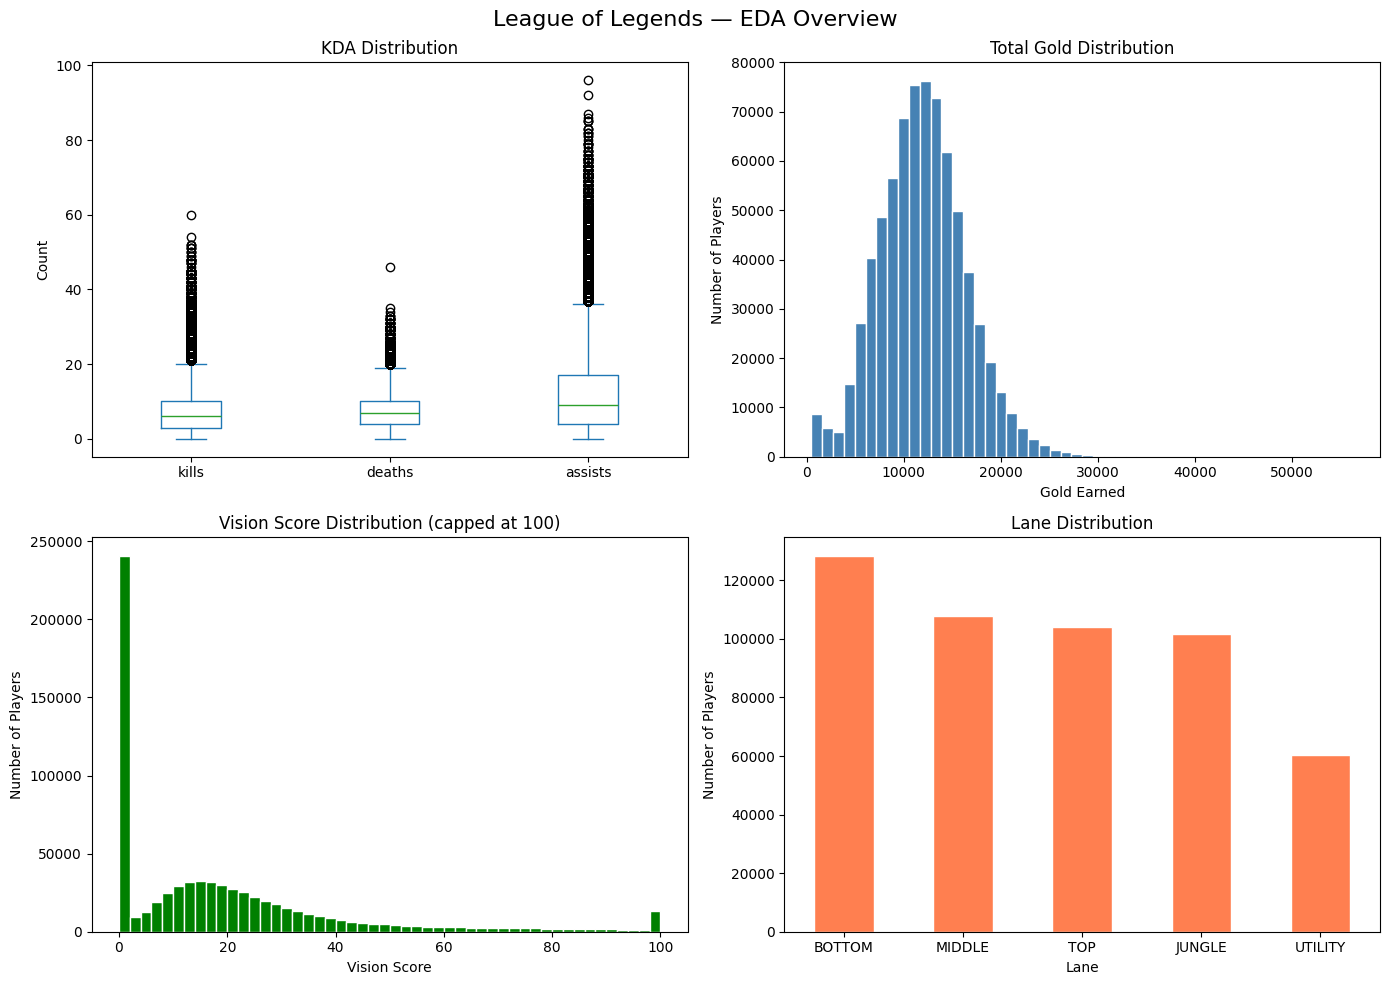

Chart saved as eda_overview.png


In [ ]:
# ============================================================
# STEP 11: Visualize key distributions
# Charts help us spot patterns and outliers visually
# These will also be saved to your outputs/ folder on GitHub
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('League of Legends — EDA Overview', fontsize=16)

# Chart 1: KDA components distribution
# Shows typical kills/deaths/assists ranges across all players
match_stats[['kills', 'deaths', 'assists']].plot(
    kind='box', ax=axes[0,0], title='KDA Distribution'
)
axes[0,0].set_ylabel('Count')

# Chart 2: Total Gold distribution
# Gold earned = proxy for how well a player performed
# Bell curve expected around 12K gold
axes[0,1].hist(match_stats['TotalGold'], bins=50, color='steelblue', edgecolor='white')
axes[0,1].set_title('Total Gold Distribution')
axes[0,1].set_xlabel('Gold Earned')
axes[0,1].set_ylabel('Number of Players')

# Chart 3: Vision Score distribution
# High vision score = good map awareness = typically wins more
# We expect most players to cluster low, supports to be high
axes[1,0].hist(match_stats['visionScore'].clip(0, 100), bins=50, color='green', edgecolor='white')
axes[1,0].set_title('Vision Score Distribution (capped at 100)')
axes[1,0].set_xlabel('Vision Score')
axes[1,0].set_ylabel('Number of Players')

# Chart 4: Lane distribution (excluding nulls and NONE)
# Shows how many players per role in our dataset
lane_counts = match_stats[match_stats['Lane'].isin(
    ['TOP','JUNGLE','MIDDLE','BOTTOM','UTILITY']
)]['Lane'].value_counts()
lane_counts.plot(kind='bar', ax=axes[1,1], color='coral', edgecolor='white')
axes[1,1].set_title('Lane Distribution')
axes[1,1].set_xlabel('Lane')
axes[1,1].set_ylabel('Number of Players')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as eda_overview.png")